In [9]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/b9/c5/fc1b368f303087d20e8c9bf3d6ceb186263cfac0ade735cd938538bea839/pandas-3.0.3-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/04/a1/4571fc46e7702de8d0c2dc54ad1b2f8e29328dea3ee90831181f7353d93c/matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 546.1 kB/s eta 0:00:00
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for scikit-learn from https://files.pyt


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
 # TODO: Importación de librerias

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
 # TODO: Cargar dataset

df = pd.read_csv("../data/Teen_Mental_Health_Dataset.csv")

In [3]:
 # TODO: Exploración del dataset

print("Información del dataset:")
print(df.head())

Información del dataset:
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low       

In [4]:
 # TODO: Tamaño del dataset
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(1200, 13)


In [5]:
 # TODO: Información dataset
print("Información general:")
df.info()

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140.4 K

In [6]:
 # TODO: Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [7]:
 # TODO: Verificar cantidad de datos duplicados

print("Cantidad de registros duplicados:")
print(df.duplicated().sum())

Cantidad de registros duplicados:
0


In [8]:
 # TODO: Eliminar valores duplicados

df = df.drop_duplicates()

print("Dimensiones después de eliminar duplicados:")
print(df.shape)


Dimensiones después de eliminar duplicados:
(1200, 13)


Distribucion depression_label:
depression_label
0    1169
1      31
Name: count, dtype: int64


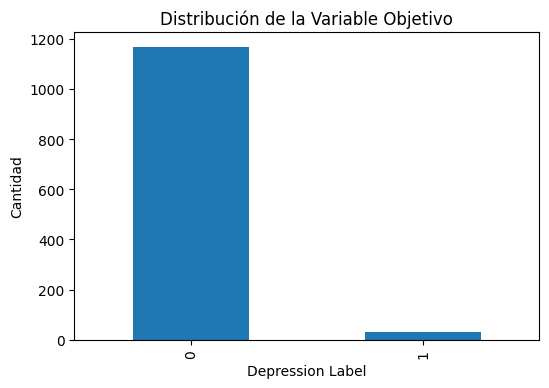

In [9]:
 # TODO EDA - EXPLORATORY DATA ANALYSIS

#! Distribución del target

print("Distribucion depression_label:")
print(df["depression_label"].value_counts())

plt.figure(figsize=(6,4))

df["depression_label"].value_counts().plot(kind="bar")

plt.title("Distribución de la Variable Objetivo")
plt.xlabel("Depression Label")
plt.ylabel("Cantidad")

plt.show()

age
13    200
15    180
18    172
17    170
16    163
19    162
14    153
Name: count, dtype: int64


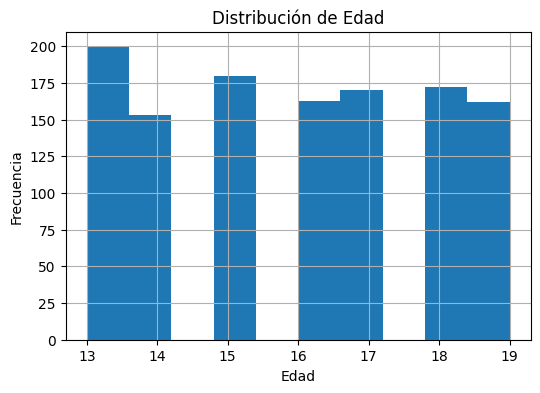

In [10]:
 #! Histograma EDAD

plt.figure(figsize=(6,4))

df["age"].hist()
print(df["age"].value_counts())

plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

gender
male      615
female    585
Name: count, dtype: int64


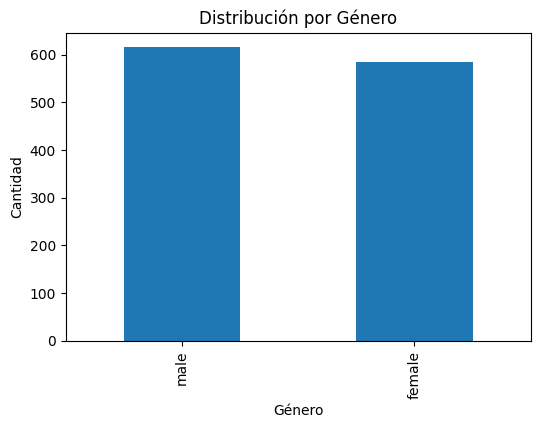

In [11]:
 #! Distribución GENERO

plt.figure(figsize=(6,4))

df["gender"].value_counts().plot(kind="bar")
print(df["gender"].value_counts())

plt.title("Distribución por Género")
plt.xlabel("Género")
plt.ylabel("Cantidad")

plt.show()

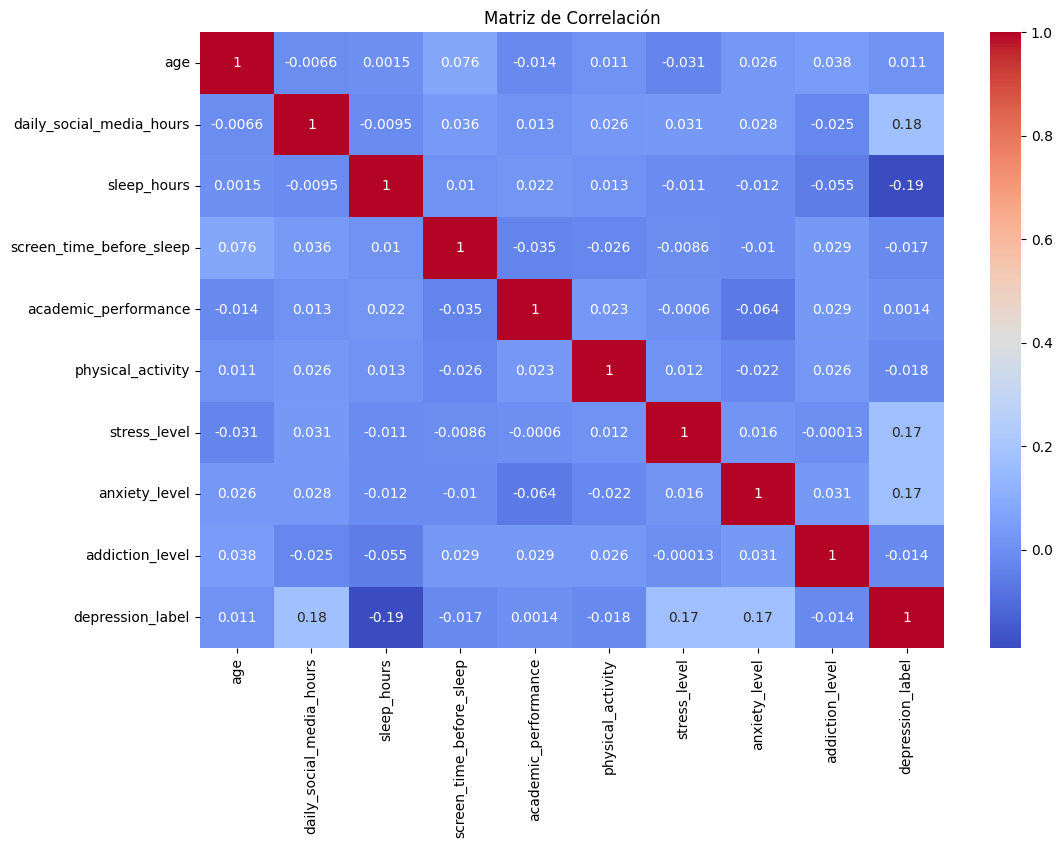

In [12]:
 #! Matriz de correlación

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de Correlación")

plt.show()

In [13]:
 # TODO: Preprocesamiento

#! Definir X e Y

#* Variable objeto
y = df["depression_label"]

#* Variables predictoras
x = df.drop("depression_label", axis=1)

#! Variables categoricas

print("Columnas antes del encoding:")
print(x.columns)

#* One Hot Encoding

x = pd.get_dummies(x, drop_first=True)

print("\nColumnas después del encoding:")
print(x.columns)

Columnas antes del encoding:
Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level'],
      dtype='str')

Columnas después del encoding:
Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'gender_male',
       'platform_usage_Instagram', 'platform_usage_TikTok',
       'social_interaction_level_low', 'social_interaction_level_medium'],
      dtype='str')


In [14]:
 #! Train / Test

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("\nDatos de entrenamiento:")
print(x_train.shape)

print("\nDatos de prueba:")
print(x_test.shape)

#! Escalamiento

scaler = StandardScaler()

#* Ajustar entrenamiento
x_train_scaled = scaler.fit_transform(x_train)

#* Transformar prueba
x_test_scaled = scaler.transform(x_test)

print("\nEscalamiento realizado correctamente")


Datos de entrenamiento:
(960, 14)

Datos de prueba:
(240, 14)

Escalamiento realizado correctamente


In [15]:
 # TODO: Resultados

print("\nPrimeras filas escaladas:")
print(x_train_scaled[:5])

print("\nPrimeras etiquetas:")
print(y_train.head())


Primeras filas escaladas:
[[ 0.02042178  0.76642066  1.13584497 -0.47654645  0.4763754   1.02962929
   1.56466523 -1.59878278 -0.55321941 -1.01892912  1.39780047 -0.69718585
   1.38169856 -0.73044255]
 [-0.46970086  0.56945537  0.72092443  0.91525333 -0.26816407  0.51302087
   1.56466523  1.56002884 -1.25618517 -1.01892912  1.39780047 -0.69718585
  -0.72374686  1.36903305]
 [-1.44994614 -1.69564544  0.44431074  0.08017347 -0.77029533 -0.34799318
  -0.14185445 -0.1948665   1.55567787  0.98142253 -0.71540969  1.43433777
  -0.72374686 -0.73044255]
 [ 0.02042178  0.37249008 -1.4919851  -0.33736647 -0.78761021 -1.20900722
   0.54075342  0.50709163  1.55567787 -1.01892912 -0.71540969  1.43433777
  -0.72374686 -0.73044255]
 [-0.9598235   0.91414463 -0.31637691 -0.89408638  1.41137844 -0.17579037
   0.88205736 -1.24780371 -0.90470229 -1.01892912  1.39780047 -0.69718585
  -0.72374686  1.36903305]]

Primeras etiquetas:
331    0
409    0
76     0
868    1
138    0
Name: depression_label, dtype: 

# **Implementacion del modelo**

In [16]:
model = LogisticRegression()

In [17]:
model.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [18]:
y_pred = model.predict(x_test_scaled)

In [19]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9916666666666667


In [20]:
# Precision

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 1.0


In [21]:
# Recall

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.6666666666666666


In [22]:
# F1-Score
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8


[[234   0]
 [  2   4]]


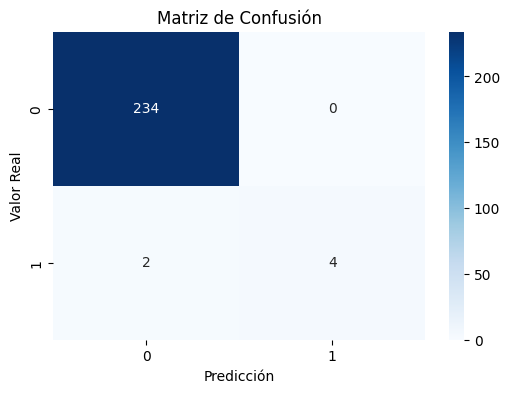

In [23]:
# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [24]:
# Resultados
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       234
           1       1.00      0.67      0.80         6

    accuracy                           0.99       240
   macro avg       1.00      0.83      0.90       240
weighted avg       0.99      0.99      0.99       240



# RED NEURONAL

In [71]:
 #! Arquitectura (MLP)

nn_model = Sequential([

    Dense(
        64,
        activation="relu",
        input_shape=(x_train_scaled.shape[1],)
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])

c:\Users\yaelc\Desktop\IA\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
 #! Compilación

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [73]:
 #! Checkpoint

checkpoint = ModelCheckpoint(
    "best_depression_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [96]:
 #! Clase pesos

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

print(class_weights)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

[ 0.51336898 19.2       ]
{0: np.float64(0.5133689839572193), 1: np.float64(19.2)}


In [ ]:
 #! Entrenamiento 

history = nn_model.fit(
    x_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[checkpoint],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
26/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5255 - loss: 0.7564 
Epoch 1: val_accuracy improved from None to 0.83854, saving model to best_depression_model.keras

Epoch 1: finished saving model to best_depression_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7214 - loss: 0.5923 - val_accuracy: 0.8385 - val_loss: 0.5079
Epoch 2/100
35/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9367 - loss: 0.3846 
Epoch 2: val_accuracy improved from 0.83854 to 0.88021, saving model to best_depression_model.keras

Epoch 2: finished saving model to best_depression_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9180 - loss: 0.4126 - val_accuracy: 0.8802 - val_loss: 0.3696
Epoch 3/100
22/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9118 - loss: 0.2405 
Epoch 3: val_accuracy improved from 0.88021 to 0.91667, saving model to best_depression_model.keras

Epoch 3: finished saving model to best_depression_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━

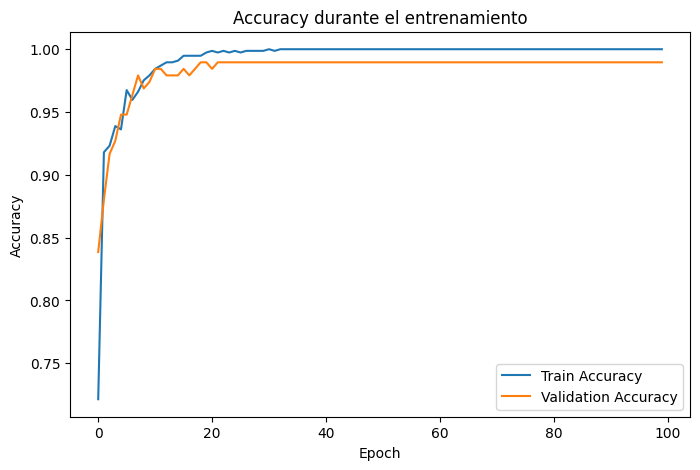

In [106]:
 #! Presición del modelo

plt.figure(figsize=(8,5)) 

plt.plot(
    history.history["accuracy"], 
    label="Train Accuracy" 
) 

plt.plot( 
    history.history["val_accuracy"],
    label="Validation Accuracy" 
) 

plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Epoch") 
plt.ylabel("Accuracy") 

plt.legend() 
plt.show()

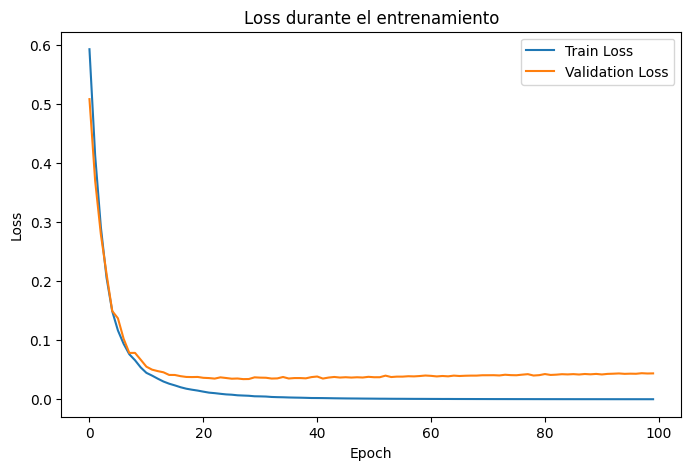

In [ ]:
 #! Error

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
 #! Predicción

y_pred_prob = nn_model.predict( x_test_scaled )
print(y_pred_prob)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
[[1.1211628e-08]
 [7.7734326e-09]
 [1.0879995e-12]
 [3.6395545e-10]
 [3.2662516e-08]
 [4.1689300e-06]
 [8.0102211e-07]
 [1.9794129e-01]
 [2.8261999e-11]
 [7.0821153e-12]
 [3.2224037e-08]
 [2.5711281e-04]
 [8.7618734e-16]
 [7.7098889e-07]
 [1.6703874e-08]
 [2.6068481e-14]
 [1.4089782e-08]
 [2.0071399e-11]
 [2.2857882e-09]
 [1.2081043e-12]]


In [ ]:
 #! Umbral

y_pred_nn = (y_pred_prob > 0.3).astype(int)

print(y_pred_nn)

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]


In [100]:
 #! Accuracy
accuracy_nn = accuracy_score(y_test, y_pred_nn)

print("Accuracy:",accuracy_nn)

Accuracy: 0.975


In [101]:
 #! Precision
precision_nn = precision_score(y_test, y_pred_nn)

print("Precision:", precision_nn)

Precision: 0.5


In [102]:
#! Recall
recall_nn = recall_score(y_test, y_pred_nn)

print("Recall:", recall_nn)

Recall: 0.6666666666666666


In [103]:
 #! F1-Score

f1_nn = f1_score(y_test,y_pred_nn)

print("F1-Score:", f1_nn)

F1-Score: 0.5714285714285714


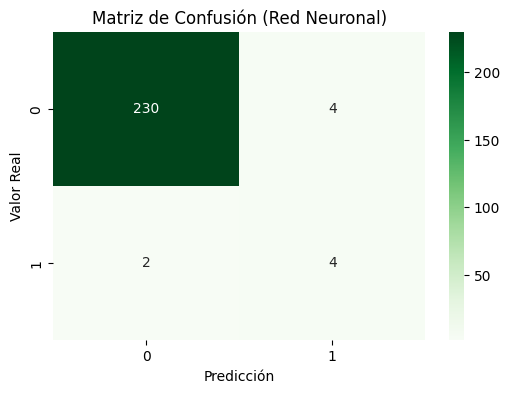

In [104]:
 #! Matriz de confusión Red Neuronal

cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nn,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Matriz de Confusión (Red Neuronal)")

plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [105]:
 #? Resultados de las métricas 
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       234
           1       0.50      0.67      0.57         6

    accuracy                           0.97       240
   macro avg       0.75      0.82      0.78       240
weighted avg       0.98      0.97      0.98       240



In [86]:
print("Regresión logistica")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nRed neuronal")
print("Accuracy:", accuracy_nn)
print("Precision:", precision_nn)
print("Recall:", recall_nn)
print("F1:", f1_nn)

Regresión logistica
Accuracy: 0.9916666666666667
Precision: 1.0
Recall: 0.6666666666666666
F1: 0.8

Red neuronal
Accuracy: 0.9791666666666666
Precision: 0.5714285714285714
Recall: 0.6666666666666666
F1: 0.6153846153846154


In [87]:
best_model = load_model("./best_depression_model.keras")

In [88]:
best_model.save("../models/depression_model.keras")

In [89]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [90]:
joblib.dump(x.columns.tolist(), "../models/columns.pkl")

['../models/columns.pkl']